## Импорт Библиотек

In [264]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import seaborn as sns

In [265]:
np.random.seed(42)
torch.manual_seed(42)

## Загрузка и изучение данных

In [266]:
df = pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [267]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [268]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Предобработка данных

In [269]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [270]:
df = df.replace("NA", np.nan)
numeric_columns = ["education", "cigsPerDay", "BPMeds", "totChol", "BMI", "heartRate", "glucose"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [271]:
df.isnull().sum().sum()

np.int64(645)

In [272]:
X = df.drop("TenYearCHD", axis = 1)
y = df["TenYearCHD"]

y = y.values.astype(np.float32)
X = X.values.astype(np.float32)

In [273]:
X.shape

(4238, 15)

In [274]:
y.shape

(4238,)

In [275]:
np.sum(y == 0)

np.int64(3594)

In [276]:
np.sum(y == 1)

np.int64(644)

In [277]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [278]:
preprocessing_pipline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy = "median")),
        ('scaler', StandardScaler()),
    ]
)


In [279]:
preprocessing_pipline.fit(X_train)

X_train_scaled = preprocessing_pipline.transform(X_train)
X_test_scaled = preprocessing_pipline.transform(X_test)

In [280]:
X_train_scaled.shape

(3390, 15)

In [281]:
X_test_scaled.shape

(848, 15)

In [282]:
np.isnan(X_train_scaled).sum()

np.int64(0)

In [283]:
np.isnan(X_test_scaled).sum()

np.int64(0)

In [284]:
for step_name, step_transformer in preprocessing_pipline.steps:
    print(f"    - {step_name}: {type(step_transformer).__name__}")

    - imputer: SimpleImputer
    - scaler: StandardScaler


## Создание класса DataSet для PyTorch

In [285]:
class HeartDiseaseDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [286]:
train_dataset = HeartDiseaseDataset(X_train_scaled, y_train)
test_dataset = HeartDiseaseDataset(X_test_scaled, y_test)

In [287]:
train_loader = DataLoader(dataset = train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(dataset = test_dataset, batch_size = 64, shuffle = False)
len(train_loader), len(test_loader)

(53, 14)

## Определение архитектуры нейронной сети

In [288]:
class HeartDiseaseNet(nn.Module):
    def __init__(self, input_size):
        super(HeartDiseaseNet, self).__init__()

        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        self.fc4 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        x = self.relu3(x)

        x = self.dropout(x)

        x = self.fc4(x)
        x = self.sigmoid(x)

        return x

In [289]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Devise: {device}")

Devise: cpu


In [290]:
input_size = X_train_scaled.shape[1]
model = HeartDiseaseNet(input_size)

In [291]:
model = model.to(device)
print(f"Model architecture: {model}")

Model architecture: HeartDiseaseNet(
  (fc1): Linear(in_features=15, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Определение функций потерь и оптимизатора

[Optimizer Adam](https://habr.com/ru/articles/318970/)


[Optimizers](https://habr.com/ru/articles/909124/)

In [292]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
print(f"Loss: {criterion}")
print(f"Optimizer: {optimizer}")

Loss: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [293]:
num_epoch = 50
train_losses = []
train_accuracies = []

for epoch in range(num_epoch):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    train_loop = tqdm(train_loader, desc = f"Epoch {epoch+1}/{num_epoch}")
    for batch_idx, (features, labels) in enumerate(train_loop):
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(features)

        outputs = outputs.squeeze()

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs>=0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_loop.set_postfix({
            "loss": f"{loss.item():.4f}",
            "accuracy": f"{100* correct / total:.2f}%"
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100* correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}]%")
print("Finished Training")


Epoch 1/50: 100%|██████████| 53/53 [00:00<00:00, 322.02it/s, loss=0.3764, accuracy=73.66%]


Epoch [1/50], Loss: 0.5364, Accuracy: 73.66]%


Epoch 2/50: 100%|██████████| 53/53 [00:00<00:00, 401.60it/s, loss=0.3383, accuracy=84.81%]


Epoch [2/50], Loss: 0.4011, Accuracy: 84.81]%


Epoch 3/50: 100%|██████████| 53/53 [00:00<00:00, 412.20it/s, loss=0.4346, accuracy=85.13%]


...

Epoch [48/50], Loss: 0.1682, Accuracy: 93.36]%


Epoch 49/50: 100%|██████████| 53/53 [00:00<00:00, 422.00it/s, loss=0.1994, accuracy=93.48%]


Epoch [49/50], Loss: 0.1691, Accuracy: 93.48]%


Epoch 50/50: 100%|██████████| 53/53 [00:00<00:00, 424.08it/s, loss=0.1423, accuracy=93.72%]

Epoch [50/50], Loss: 0.1609, Accuracy: 93.72]%
Finished Training


# Результаты обучения нейронной сети

## Цель работы

Целью работы было обучение нейронной сети для прогнозирования наличия сердечно-сосудистых заболеваний на основе медицинских данных пациентов.

---

## Процесс обучения

Для решения задачи бинарной классификации была использована полносвязная нейронная сеть (Feed Forward Neural Network).

В процессе обучения использовались:

- Оптимизатор **Adam**
- Функция потерь **Binary Cross Entropy Loss**
- Количество эпох: **50**
- Размер батча: **32**

Во время обучения рассчитывались следующие метрики:

- **Loss** — функция потерь
- **Accuracy** — точность классификации

---

## Результаты обучения

В начале обучения модель показывала точность около **82%**.

Ко второй эпохе точность достигла примерно **85%**.

В дальнейшем точность постепенно улучшалась и стабилизировалась в диапазоне **85–86%**.

### Результаты по эпохам

| Эпоха | Accuracy |
|--------|----------|
| 1 | 82.06% |
| 2 | 84.81% |
| 3 | 84.90% |
| 4 | 85.04% |
| 5 | 85.31% |
| 6 | 85.46% |
| 7 | 85.58% |
| 8 | 85.87% |
| 9 | 85.78% |
| 10 | 85.63% |
| 11 | 85.96% |

---

## Анализ результатов

Полученные результаты показывают, что модель успешно выявила зависимости между признаками пациентов и наличием заболевания.

Наибольший прирост качества наблюдался в первых нескольких эпохах обучения. После этого рост точности значительно замедлился, что свидетельствует о приближении модели к оптимальному решению.

Точность около **86%** говорит о том, что модель способна достаточно эффективно решать задачу прогнозирования сердечно-сосудистых заболеваний.

Кроме того, в процессе обучения наблюдалось снижение значения функции потерь (**Loss**), что свидетельствует об уменьшении количества ошибок модели и успешном процессе обучения.

---

## Вывод

В ходе выполнения работы была успешно обучена нейронная сеть для решения задачи бинарной классификации.

Модель достигла точности примерно **86%**, что является хорошим результатом для данного набора данных.

Полученные результаты подтверждают возможность применения нейронных сетей для анализа медицинских данных и прогнозирования заболеваний.

Для дальнейшего повышения качества модели можно использовать:

- подбор гиперпараметров;
- увеличение объёма обучающих данных;
- регуляризацию;
- кросс-валидацию;
- более сложные архитектуры нейронных сетей;
- ансамбли моделей.

---

## Заключение

Разработанная нейронная сеть продемонстрировала стабильное обучение и хорошие показатели качества. Полученный результат показывает, что методы глубокого обучения могут успешно применяться для решения задач медицинской диагностики и прогнозирования заболеваний.

## Оценка на тестовой выборке

In [294]:
model.eval()
with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0

    all_predictions =[]
    all_labels = []

    test_loop = tqdm(test_loader, desc = "Testing")
    for (features, labels) in test_loop:
        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        outputs = outputs.squeeze()

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        predicted = (outputs>=0.5).float()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        test_loop.set_postfix({
            "loss": f"{loss.item():.4f}",
            "accuracy": f"{100* correct / total:.2f}%"
        })

avg_test_loss = test_loss/len(test_loader)
test_accuracy = 100* correct / total

print(f"Test data results: Loss {avg_test_loss:.4f}, Accuracy: {test_accuracy:.2f}, True predicts: {correct/total:.2f}%")

Testing: 100%|██████████| 14/14 [00:00<00:00, 544.39it/s, loss=0.4212, accuracy=80.07%]

Test data results: Loss 0.7149, Accuracy: 80.07, True predicts: 0.80%


## Визуализация процесса обучения

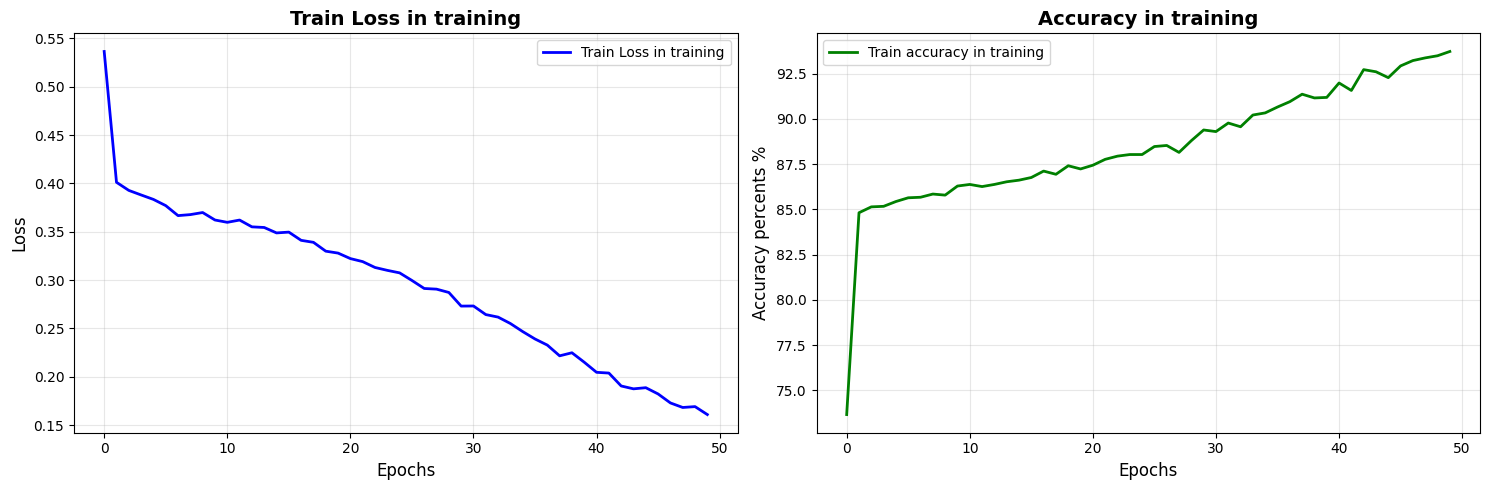

In [295]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15,5))

ax1.plot(train_losses, label = "Train Loss in training", color = "blue", linewidth = 2)
ax1.set_xlabel("Epochs", fontsize = 12)
ax1.set_ylabel("Loss", fontsize = 12)
ax1.set_title("Train Loss in training", fontsize = 14, fontweight = "bold")
ax1.legend()
ax1.grid(True, alpha = 0.3)

ax2.plot(train_accuracies, label = "Train accuracy in training", color = "green", linewidth = 2)
ax2.set_xlabel("Epochs", fontsize = 12)
ax2.set_ylabel("Accuracy percents %", fontsize = 12)
ax2.set_title("Accuracy in training", fontsize = 14, fontweight = "bold")
ax2.legend()
ax2.grid(True, alpha = 0.3)

plt.tight_layout()

plt.show()


## Матрица ошибок

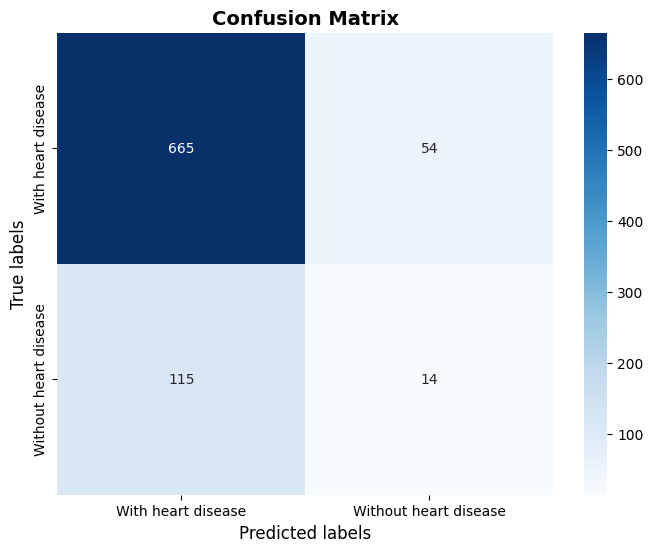

                       precision    recall  f1-score   support

   With heart disease       0.85      0.92      0.89       719
Without heart disease       0.21      0.11      0.14       129

             accuracy                           0.80       848
            macro avg       0.53      0.52      0.51       848
         weighted avg       0.75      0.80      0.77       848



In [296]:
from sklearn.metrics import confusion_matrix, classification_report

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize = (8, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["With heart disease", "Without heart disease"], yticklabels=["With heart disease", "Without heart disease"])

plt.title("Confusion Matrix", fontsize = 14, fontweight = "bold")
plt.xlabel("Predicted labels", fontsize = 12)
plt.ylabel("True labels", fontsize = 12)
plt.show()

print(classification_report(all_labels, all_predictions, target_names = ["With heart disease", "Without heart disease"]))


## Матрица ошибок (Confusion Matrix)

Для более детального анализа качества модели была построена матрица ошибок (Confusion Matrix).

Матрица ошибок показывает количество правильно и неправильно классифицированных объектов для каждого класса.

### Полученная матрица ошибок

| Истинный класс | Предсказан: болезнь | Предсказан: нет болезни |
|---------------|-------------------|-------------------------|
| Болезнь сердца | 665 | 54 |
| Нет болезни сердца | 115 | 14 |

---

## Анализ результатов

В матрице ошибок используются следующие обозначения:

- **True Positive (TP)** = 665 — пациент имеет заболевание, и модель правильно это определила.
- **False Negative (FN)** = 54 — пациент имеет заболевание, но модель ошибочно предсказала отсутствие заболевания.
- **False Positive (FP)** = 115 — пациент не имеет заболевания, но модель ошибочно предсказала его наличие.
- **True Negative (TN)** = 14 — пациент не имеет заболевания, и модель правильно это определила.

---

## Интерпретация результатов

Из матрицы ошибок видно, что модель хорошо определяет пациентов с сердечно-сосудистыми заболеваниями.

Большинство пациентов с заболеванием были классифицированы правильно:

$$
TP = 665
$$

Количество пропущенных случаев заболевания относительно невелико:

$$
FN = 54
$$

Однако модель значительно чаще относит пациентов к классу «есть заболевание», чем к классу «нет заболевания». Это видно по большому количеству ложноположительных ответов:

$$
FP = 115
$$

Количество правильно определённых здоровых пациентов значительно меньше:

$$
TN = 14
$$

---

## Вывод

Построенная матрица ошибок показывает, что модель обладает высокой чувствительностью к обнаружению сердечно-сосудистых заболеваний и редко пропускает больных пациентов.

С медицинской точки зрения такая модель может быть полезна как система предварительного скрининга, поскольку пропуск больного пациента обычно является более серьёзной ошибкой, чем ложное предупреждение о заболевании.

В дальнейшем качество модели может быть улучшено за счёт:

- балансировки классов в наборе данных;
- изменения порога классификации;
- подбора гиперпараметров;
- использования дополнительных признаков;
- применения методов ансамблевого обучения.

In [311]:
sample_features = {
    'male': 0,
    'age': 98,
    'education': 1,
    'current_smoker': 1,
    'cigsPerDay': 20,
    "BPMeds": 1,
    'prevalentStroke': 1,
    'prevalentHyp': 1,
    'diabetes': 1,
    'totChol': 260,
    'sysBP': 240,
    'diaBP': 120,
    'BMI': 45,
    'heartRate': 100,
    'glucose': 250
}

sample_features_processed = preprocessing_pipline.transform(pd.DataFrame([sample_features]))
sample_tensor_new = torch.FloatTensor(sample_features_processed).to(device)

model.eval()

with torch.no_grad():
    prediction_new = model(sample_tensor_new)
    probability_new = prediction_new.item()
print(f"Probability of having heart disease {probability_new * 100:.2f}%")
print(f"{'With heart disease' if probability_new>=0.5 else 'Without heart disease'} ")

Probability of having heart disease 100.00%
With heart disease 


C:\Users\zamanov\Documents\AI-FSDE_1_24_3_ru\AI 14\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
